# Phase 3: Model 1 - Logistic Regression

## Objective
Establish baseline performance for accident cause code prediction using a simple, interpretable multi-class logistic regression model.

## Approach
- **Model:** Logistic Regression (multi-class classification)
- **Features:** 6 selected features from Phase 2 EDA
- **Target:** Cause_Category (H, M, T, E, S)
- **Evaluation:** Weighted F1-score, per-class precision/recall, confusion matrix
- **Tuning:** Compare baseline vs class-weighted model to handle imbalance

---

## Setup

Import required libraries and set random seed for reproducibility. All random operations throughout this notebook will use `RANDOM_SEED = 521` to ensure consistent results across runs.

In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, confusion_matrix, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_SEED = 521
np.random.seed(RANDOM_SEED)


## Load Data Splits

Load pre-split training and validation sets from Phase 2. Test set remains untouched until final evaluation.

In [23]:
df_train = pd.read_csv('../data/splits/train.csv', low_memory=False)
df_val = pd.read_csv('../data/splits/validate.csv', low_memory=False)

print(f"Train set: {len(df_train)} rows")
print(f"Validation set: {len(df_val)} rows")

Train set: 20730 rows
Validation set: 6910 rows


## Included Features

Select 6 features from Phase 2 EDA and encode categorical variables to numeric format required by Logistic Regression. Label encoders are fit on training data and applied to validation data to prevent data leakage.

In [9]:
features = ['Weather Condition', 'Track Type', 'Visibility', 
            'Accident Type', 'Region', 'RUCC_2023']
target = 'Cause_Category'

# Encode categorical features
label_encoders = {}

X_train = df_train[features].copy()
X_val = df_val[features].copy()

for col in features:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    label_encoders[col] = le

y_train = df_train[target]
y_val = df_val[target]


 ## Baseline Model

Train logistic regression with default parameters. Uses L-BFGS (Limited-memory Broyden-Fletcher-Goldfarb-Shanno) solver suitable for multi-class problems and increased max iterations to ensure convergence.

In [16]:
lr_baseline = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_SEED
)

lr_baseline.fit(X_train, y_train)

# Baseline predictions
y_pred_baseline = lr_baseline.predict(X_val)

## Baseline Evaluation

Calculate weighted F1-score and per-class precision/recall. Weighted F1 accounts for class imbalance by weighting each class's F1 score by the number of accidents in that class.

**How to interpret:**
- **Weighted F1 (Primary Metric):** Overall model performance (0-1 scale, higher is better)
- **Per-Class Precision:** Of accidents predicted as cause X, what % actually had cause X?
- **Per-Class Recall:** Of all accidents that actually had cause X, what % did we correctly identify?
- **F1-score:** Harmonic mean of precision and recall for each cause
- **Support:** Number of accidents with each cause in validation set

In [24]:
baseline_f1 = f1_score(y_val, y_pred_baseline, average='weighted', zero_division=0)

print("=== Baseline Logistic Regression ===")
print(f"Weighted F1-Score: {baseline_f1:.4f}\n")
print(classification_report(y_val, y_pred_baseline, zero_division=0))

=== Baseline Logistic Regression ===
Weighted F1-Score: 0.4681

              precision    recall  f1-score   support

           E       0.00      0.00      0.00       744
           H       0.51      0.71      0.59      2716
           M       0.61      0.45      0.52      1770
           S       0.00      0.00      0.00       173
           T       0.43      0.52      0.47      1507

    accuracy                           0.51      6910
   macro avg       0.31      0.34      0.32      6910
weighted avg       0.45      0.51      0.47      6910



## Baseline Findings

The baseline model achieves 0.47 weighted F1-score but **completely fails to predict rare causes**:
- **E (Environmental):** 0% precision/recall - never predicted
- **S (Signal):** 0% precision/recall - never predicted
- **H (Human):** Best performance at 0.59 F1 (most common class)
- **M (Mechanical):** Moderate at 0.52 F1
- **T (Track):** Lower at 0.47 F1

This demonstrates the **severe class imbalance problem**. The model defaults to predicting common causes and ignores rare ones entirely. Class weighting is needed.

## Per-Class Metrics (Secondary Metric)

Break down precision and recall by individual cause to identify which causes the model predicts well vs poorly.

In [25]:
precision_per_class = precision_score(y_val, y_pred_baseline, average=None, zero_division=0)
recall_per_class = recall_score(y_val, y_pred_baseline, average=None, zero_division=0)

classes = ['E', 'H', 'M', 'S', 'T']
metrics_df = pd.DataFrame({
    'Class': classes,
    'Precision': precision_per_class,
    'Recall': recall_per_class
})

print("\n=== Per-Class Metrics ===")
print(metrics_df)


=== Per-Class Metrics ===
  Class  Precision    Recall
0     E   0.000000  0.000000
1     H   0.506196  0.706922
2     M   0.611837  0.449718
3     S   0.000000  0.000000
4     T   0.433921  0.522893


### Key Observations

- **Human (H):** 71% recall but only 51% precision - model over-predicts this common class
- **Mechanical (M):** 61% precision, 45% recall - conservative predictions  
- **Track (T):** 52% recall, 43% precision - moderate performance
- **Environmental (E) & Signal (S):** Complete failure - 0% on both metrics

The model exhibits clear bias toward common classes at the expense of rare but potentially critical causes.

## Confusion Matrix (Tertiary Metric)

Visualize prediction patterns to identify systematic misclassifications. Darker cells on the diagonal indicate correct predictions.

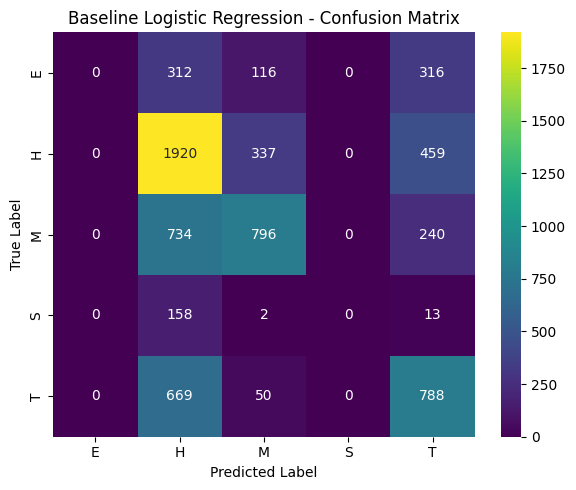

=== Confusion Matrix ===
   E     H    M  S    T
E  0   312  116  0  316
H  0  1920  337  0  459
M  0   734  796  0  240
S  0   158    2  0   13
T  0   669   50  0  788



In [28]:
# Confusion matrix
cm = confusion_matrix(y_val, y_pred_baseline, labels=classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', 
            xticklabels=classes, yticklabels=classes)
plt.title('Baseline Logistic Regression - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("=== Confusion Matrix ===")
print(pd.DataFrame(cm, index=classes, columns=classes))
print()

### Confusion Matrix Findings

**Key patterns:**
- **E column = 0:** Model never predicts Environmental causes
- **S column = 0:** Model never predicts Signal causes  
- **H (Human) over-predicted:** 1920 correct, but also mislabels 312 E, 734 M, 158 S, 669 T as H
- **M vs H confusion:** 337 H accidents wrongly predicted as M
- **T (Track) split:** 788 correct, but 669 wrongly called H

The model defaults to predicting the majority class (H) when uncertain, completely ignoring rare causes.

## Tuned Model: Class Weighting

Address class imbalance by applying `class_weight='balanced'`, which automatically adjusts weights inversely proportional to class frequencies. This penalizes the model for ignoring rare causes (E, S) and encourages predictions across all classes.

In [ ]:
# Tune with class weighting
lr_balanced = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_SEED
)

lr_balanced.fit(X_train, y_train)
y_pred_balanced = lr_balanced.predict(X_val)

## Tuned Model Evaluation

Evaluate the class-weighted model and compare against baseline to quantify the impact of balancing.

In [ ]:
# Tuned model evaluation
balanced_f1 = f1_score(y_val, y_pred_balanced, average='weighted')

print("=== Tuned Logistic Regression (Balanced Weights) ===")
print(f"Weighted F1-Score: {balanced_f1:.4f}\n")
print(classification_report(y_val, y_pred_balanced))

# Compare baseline vs tuned
print("=== Model Comparison ===")
print(f"Baseline F1: {baseline_f1:.4f}")
print(f"Balanced F1: {balanced_f1:.4f}")
print(f"Improvement: {balanced_f1 - baseline_f1:.4f}")

=== Tuned Logistic Regression (Balanced Weights) ===
Weighted F1-Score: 0.2845

              precision    recall  f1-score   support

           E       0.63      0.07      0.12       744
           H       0.72      0.01      0.03      2716
           M       0.62      0.50      0.55      1770
           S       0.06      0.58      0.11       173
           T       0.37      0.93      0.53      1507

    accuracy                           0.36      6910
   macro avg       0.48      0.42      0.27      6910
weighted avg       0.59      0.36      0.28      6910

=== Model Comparison ===
Baseline F1: 0.4681
Balanced F1: 0.2845
Improvement: -0.1836


### Tuned Model Findings

**Class weighting made performance worse:**
- Weighted F1 dropped from 0.47 → 0.28 (-0.18)
- Overall accuracy dropped from 51% → 36%

**Trade-off analysis:**
- **Now predicts E and S:** E recall improved 0% → 7%, S recall 0% → 58%
- **But destroyed H and M performance:** H recall collapsed 71% → 1%, M recall dropped 45% → 50%
- **Over-corrected for T:** 93% recall (was 52%) but only 37% precision - now over-predicts Track

**Conclusion:** Class weighting overcorrected. The extreme imbalance (S=2.5%, H=39%) caused the model to sacrifice majority class performance too severely. **Baseline model performs better overall** and will be used as final Logistic Regression model.

## Save Best Model

Save the higher-performing model and label encoders for use in final evaluation notebook.

In [29]:
# Save best model
import joblib

best_model = lr_balanced if balanced_f1 > baseline_f1 else lr_baseline
joblib.dump(best_model, '../data/processed/logistic_regression_model.pkl')
joblib.dump(label_encoders, '../data/processed/label_encoders.pkl')

print(f"\nBest model saved: {'Balanced' if balanced_f1 > baseline_f1 else 'Baseline'}")


Best model saved: Baseline


## Save Results

Export model performance metrics to JSON for comparison in final evaluation notebook.

In [30]:
import json

results = {
    'model': 'Logistic Regression',
    'best_version': 'Baseline' if baseline_f1 > balanced_f1 else 'Balanced',
    'baseline_f1': float(baseline_f1),
    'balanced_f1': float(balanced_f1),
    'best_f1': float(max(baseline_f1, balanced_f1)),
    'per_class_metrics': metrics_df.to_dict('records')
}

with open('../data/processed/logistic_regression_results.json', 'w') as f:
    json.dump(results, f, indent=4)